# Phase 1: EDA and Data Cleaning

**Goal:** Understand the raw data, select relevant features, engineer new ones, and save a clean version for preprocessing.

**Output:** 
- `data/processed/train_cleaned.csv`
- `data/processed/test_cleaned.csv`

**Rule:** This notebook does NOT scale or encode anything. That is Phase 2's job.

In [1]:
import sys
sys.path.append('..')  # So we can import from src/

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_loader import load_raw_train, load_raw_test

## 1. Load Raw Data

In [2]:
df = load_raw_train()
print(f"Shape: {df.shape}")
df.head()

[data_loader] Loaded train: (307511, 122)
Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## 2. Target Distribution (Class Imbalance Check)

TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


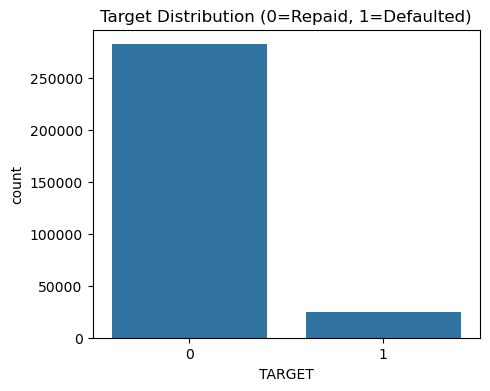

In [4]:
target_counts = df['TARGET'].value_counts()
print(target_counts)
print(f"\nDefault rate: {target_counts[1] / len(df) * 100:.2f}%")

plt.figure(figsize=(5, 4))
sns.countplot(x='TARGET', data=df)
plt.title('Target Distribution (0=Repaid, 1=Defaulted)')
plt.show()

## 3. Feature Selection

The raw dataset has 122 columns. We select only the features with strong predictive signals or domain relevance.

**Selected numerical:** Income, credit amount, annuity, EXT_SOURCE scores (external credit bureau scores — highest predictive power in this dataset), and days-based features.

**Selected categorical:** Occupation, organisation type, education, family status, income type, gender.

In [5]:
SELECTED_COLS = [
    # Target
    'TARGET',
    # Numerical
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    # Categorical
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE', 'CODE_GENDER',
]

df = df[SELECTED_COLS].copy()
print(f"After selection: {df.shape}")
df.head()

After selection: (307511, 17)


,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_INCOME_TYPE,CODE_GENDER
0,1,202500.0,406597.5,24700.5,351000.0,-9461,-637,-2120,0.083037,0.262949,0.139376,Laborers,Business Entity Type 3,Secondary / secondary special,Single / not married,Working,M
1,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,-291,0.311267,0.622246,NaN,Core staff,School,Higher education,Married,State servant,F
2,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,-2531,NaN,0.555912,0.729567,Laborers,Government,Secondary / secondary special,Single / not married,Working,M
3,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,-2437,NaN,0.650442,NaN,Laborers,Business Entity Type 3,Secondary / secondary special,Civil marriage,Working,F
4,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,-3458,NaN,0.322738,NaN,Core staff,Religion,Secondary / secondary special,Single / not married,Working,M


## 4. Missing Value Analysis

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = np.round((df.isnull().mean() * 100),2)
missing_df = pd.concat([missing,missing_percent], axis=1, keys = ["missing_count","missing_percent"])
missing_df

,missing_count,missing_percent
EXT_SOURCE_1,173378,56.38
OCCUPATION_TYPE,96391,31.35
EXT_SOURCE_3,60965,19.83
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
TARGET,0,0.00
AMT_INCOME_TOTAL,0,0.00
AMT_CREDIT,0,0.00
DAYS_ID_PUBLISH,0,0.00


**Key observations:**
- `EXT_SOURCE_1`: ~56% missing — keep but flag missingness (these are strong predictors even when present)
- `EXT_SOURCE_3`: ~20% missing — same approach
- `OCCUPATION_TYPE`: ~31% missing — fill with 'Unknown' category
- `AMT_GOODS_PRICE`: ~0.09% missing — fill with AMT_CREDIT (correlation ~0.99)

## 5. EDA: Numerical Features

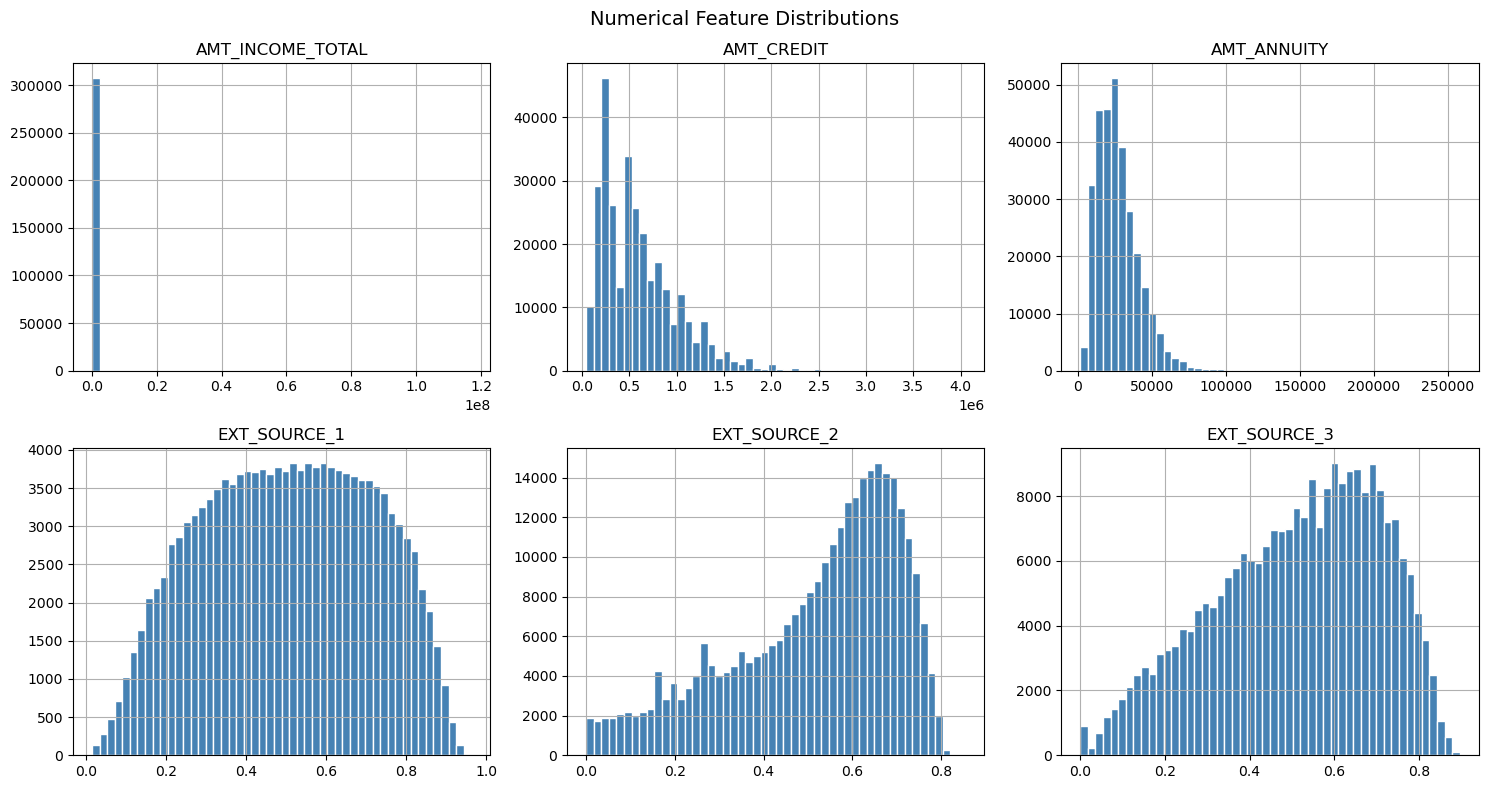

In [7]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
            'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].dropna().hist(ax=axes[i], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

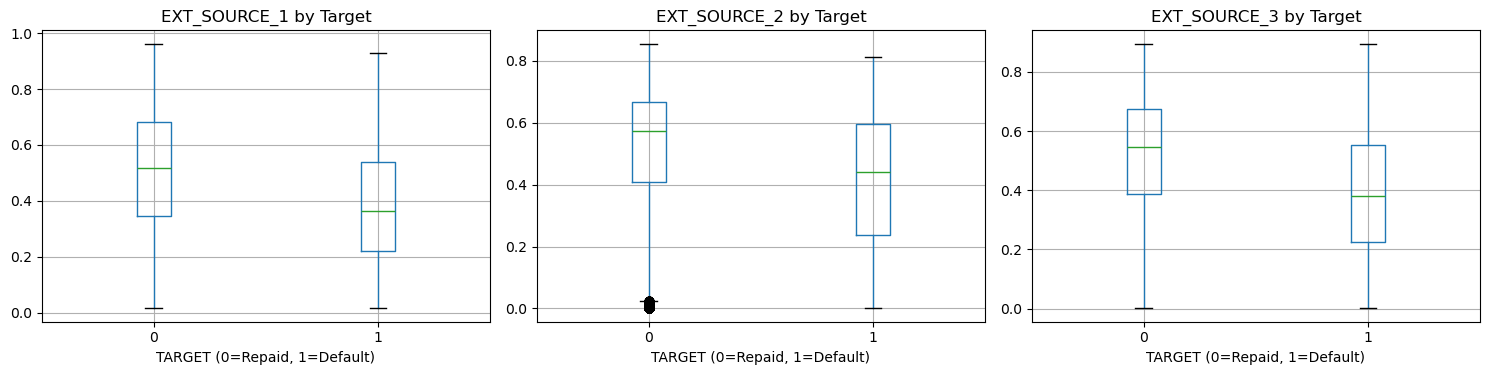

In [8]:
# EXT_SOURCE scores vs Target — the most important predictors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    df.boxplot(column=col, by='TARGET', ax=axes[i])
    axes[i].set_title(f'{col} by Target')
    axes[i].set_xlabel('TARGET (0=Repaid, 1=Default)')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 6. EDA: Categorical Features

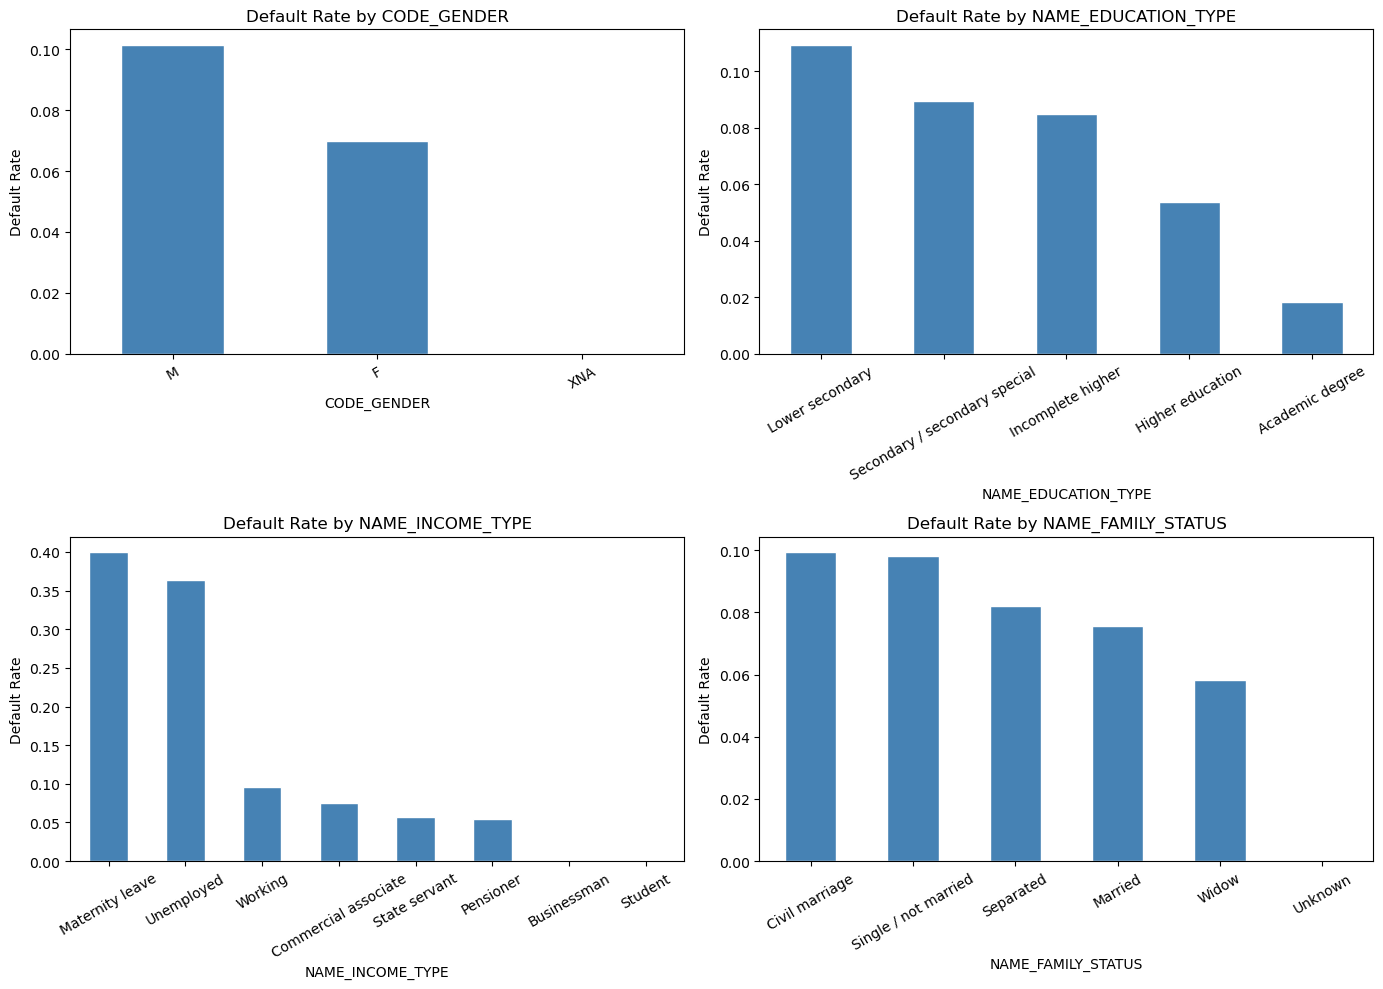

In [9]:
cat_cols = ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    default_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

AMT_CREDIT vs AMT_GOODS_PRICE correlation:
                 AMT_CREDIT  AMT_GOODS_PRICE
AMT_CREDIT         1.000000         0.986968
AMT_GOODS_PRICE    0.986968         1.000000


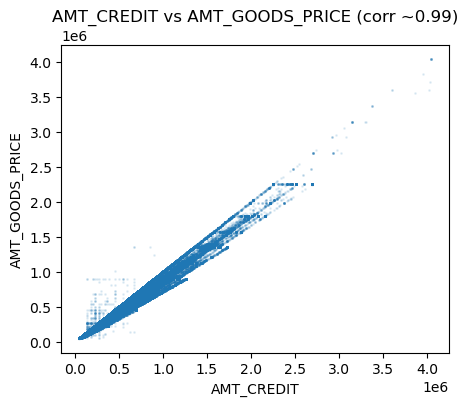

In [10]:
# Correlation between AMT_GOODS_PRICE and AMT_CREDIT
# This justifies our imputation strategy
corr = df[['AMT_CREDIT', 'AMT_GOODS_PRICE']].corr()
print("AMT_CREDIT vs AMT_GOODS_PRICE correlation:")
print(corr)

plt.figure(figsize=(5, 4))
plt.scatter(df['AMT_CREDIT'], df['AMT_GOODS_PRICE'], alpha=0.1, s=1)
plt.xlabel('AMT_CREDIT')
plt.ylabel('AMT_GOODS_PRICE')
plt.title('AMT_CREDIT vs AMT_GOODS_PRICE (corr ~0.99)')
plt.show()

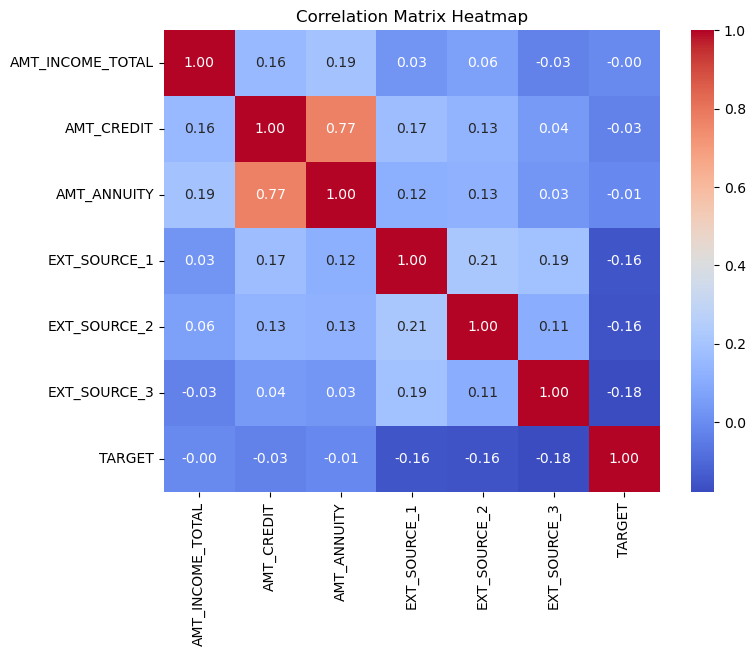

In [11]:
# Correlation heatmap for numerical features vs TARGET
num_df = df[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
             'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].copy()

corr_matrix = num_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

## 8. DAYS_EMPLOYED Anomaly Check

A known quirk in this dataset: `DAYS_EMPLOYED = 365243` is a sentinel value meaning the applicant is unemployed (or retired). It is not a real number of days.

In [12]:
print(f"Rows with DAYS_EMPLOYED = 365243: {(df['DAYS_EMPLOYED'] == 365243).sum()}")
print(f"That is {(df['DAYS_EMPLOYED'] == 365243).mean() * 100:.2f}% of the dataset")

# Default rate for unemployed vs employed
df['_IS_UNEMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
print("\nDefault rate by unemployment status:")
print(df.groupby('_IS_UNEMPLOYED')['TARGET'].mean())
df = df.drop(columns=['_IS_UNEMPLOYED'])  # Temporary column, cleaned up

Rows with DAYS_EMPLOYED = 365243: 55374
That is 18.01% of the dataset

Default rate by unemployment status:
_IS_UNEMPLOYED
0    0.086600
1    0.053996
Name: TARGET, dtype: float64


## 9. Save Cleaned Data

We save the selected columns only — no engineering yet (that happens in `preprocessor.py`). Both train and test get identical treatment.

**Important:** `index=False` prevents the `Unnamed: 0` column problem.

In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/train_cleaned.csv', index=False)
print(f"Saved train_cleaned.csv: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved train_cleaned.csv: (307511, 17)
Columns: ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE', 'CODE_GENDER']


In [14]:
# Apply exact same column selection to test set
df_test = load_raw_test()

TEST_COLS = [c for c in SELECTED_COLS if c != 'TARGET']  # test has no TARGET
df_test = df_test[TEST_COLS].copy()

df_test.to_csv('../data/processed/test_cleaned.csv', index=False)
print(f"Saved test_cleaned.csv: {df_test.shape}")

[data_loader] Loaded test: (48744, 121)
Saved test_cleaned.csv: (48744, 16)


## Summary

| Step | Decision | Reason |
|------|----------|--------|
| Feature selection | 16 from 122 columns | Domain relevance + missing % filter |
| AMT_GOODS_PRICE | Kept for ratio, dropped after | 0.99 correlation with AMT_CREDIT |
| EXT_SOURCE NaNs | Flag + impute in preprocessing | Strong predictors even when present |
| DAYS_EMPLOYED sentinel | Flag as IS_UNEMPLOYED in preprocessing | Not a real numeric value |
| OCCUPATION_TYPE NaNs | Fill 'Unknown' in preprocessing | 31% missing — meaningful category |

**Next:** Run `02_preprocessing.ipynb` to fit the scaler and encoders.